# Author prediction using RNNs

In this notebook, you will prepare a dataset to predict authorship of the Federalist Papers using Recurrent Neural Networks (RNNs).

## Federalist Papers

The Federalist Papers are a collection of 85 articles and essays written by Alexander Hamilton, James Madison, and John Jay under the pseudonym "Publius". They were published in 1787 and 1788 to promote the ratification of the United States Constitution. The authors of the Federalist Papers wanted to remain anonymous, so they used the pseudonym "Publius". The articles were published in two newspapers, the New York Packet and the Independent Journal. The Federalist Papers are considered important works of American political thought and are still widely read today.

## Additional information

- [Federalist Papers](https://en.wikipedia.org/wiki/The_Federalist_Papers)
- [Federalist Papers dataset](https://www.kaggle.com/datasets/tobyanderson/federalist-papers)
- [LOC Research Guide](https://guides.loc.gov/federalist-papers/full-text)

## Objectives (a)

- Task 1: Design your dataset to predict the author of a text using RNNs.
- Task 2: Explain the methodology of your dataset creation.
- Task 3: Establish a baseline model using Machine Learning algorithms (SVM, Random Forest, etc.).
  
## Objectives (b)

- Task 4: Train a RNN model to predict the author of a text.
- Task 5: Evaluate the performance of your model.
- Task 6: Explain your model architecture, hyperparameters, and the results of your model.

## Task 1: Dataset Creation

### Dataset description

Use the below code to scrape the Library of Congress research guide for the Federalist Papers. You need to pip install the following for the below code to work:

- `pip install beautifulsoup4`
- `pip install requests`
- `pip install pandas`

In [137]:
import pandas as pd
from io import StringIO
from bs4 import BeautifulSoup as bs
import requests

url = 'https://guides.loc.gov/federalist-papers/full-text'

html = requests.get(url).text
soup = bs(html, 'html.parser')

# convert the html table to a pandas dataframe
table = soup.find('table')

# List of Federalist Papers
meta_df = pd.read_html(StringIO(str(table)), parse_dates=True)[0]

### Dataset datatypes

In [138]:
meta_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   No.          85 non-null     float64
 1   Title        85 non-null     object 
 2   Author       85 non-null     object 
 3   Publication  85 non-null     object 
 4   Date         85 non-null     object 
dtypes: float64(1), object(4)
memory usage: 3.4+ KB


In [139]:
meta_df.head()

,No.,Title,Author,Publication,Date
0,1.0,General Introduction,Hamilton,For the Independent Journal,--
1,2.0,Concerning Dangers from Foreign Force and Infl...,Jay,For the Independent Journal,--
2,3.0,The Same Subject Continued: Concerning Dangers...,Jay,For the Independent Journal,--
3,4.0,The Same Subject Continued: Concerning Dangers...,Jay,For the Independent Journal,--
4,5.0,The Same Subject Continued: Concerning Dangers...,Jay,For the Independent Journal,--


### Autorship counts

Plot the count the number of papers written by each author. We want to create a machine learning dataset that consists of a train, validation, and test set. We will use the train set to train the model, the validation set to tune the hyperparameters, and the test set to evaluate the model.

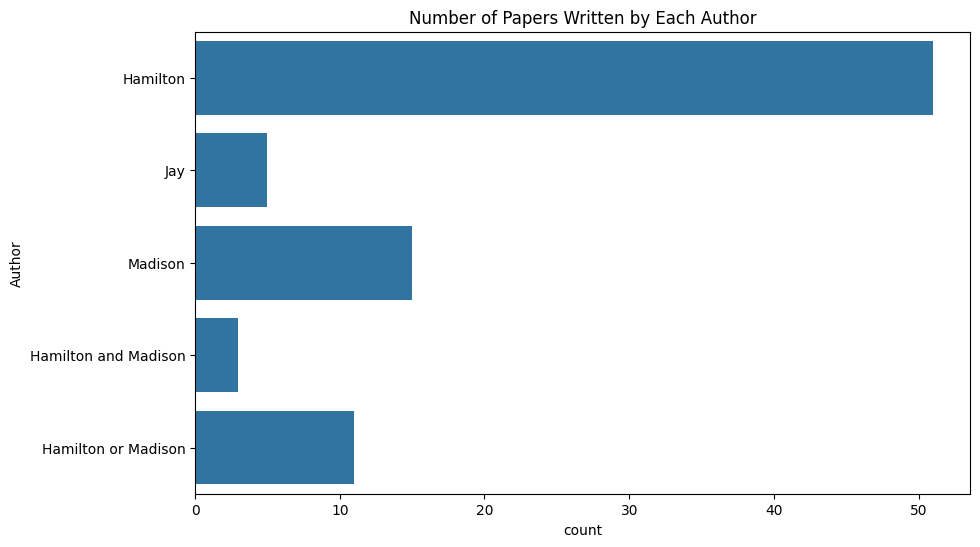

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

# plot the number of papers written by each author
plt.figure(figsize=(10, 6))
sns.countplot(y='Author', data=meta_df)
plt.title('Number of Papers Written by Each Author')
plt.show()

Based on the data, answer the following questions:

- How many papers were written by each author?
- How should you construct your dataset? Explain your reasoning.

### Contested authorship

In [141]:
# disputed papers
disputed_papers = meta_df[meta_df['Author'] == 'Hamilton or Madison']
contested_authorship = disputed_papers['No.'].values
print(f'Contested authorship of papers: {contested_authorship}')
print(f'Total number of disputed papers: {len(disputed_papers)}')

Contested authorship of papers: [49. 50. 51. 52. 53. 54. 55. 56. 57. 62. 63.]
Total number of disputed papers: 11


### Load the Federalist Papers corpus

The following code loads the Federalist Papers corpus. The papers have been preprocessed to aid your analysis of the authorship of the papers.

In [145]:
corpus = pd.read_pickle('fp_corpus.pkl')
corpus

,text,paper_id,target,sentences,sentence_length,sentence_index,total_sentences
0,Method of Guarding Against the Encroachments o...,49,dispt,Method of Guarding Against the Encroachments o...,25,0,63
0,Method of Guarding Against the Encroachments o...,49,dispt,"Tuesday, February 5, 1788.",4,1,63
0,Method of Guarding Against the Encroachments o...,49,dispt,Author: Alexander Hamilton or James Madison,6,2,63
0,Method of Guarding Against the Encroachments o...,49,dispt,To the People of the State of New York:,9,3,63
0,Method of Guarding Against the Encroachments o...,49,dispt,"THE author of the ""Notes on the State of Virgi...",56,4,63
...,...,...,...,...,...,...,...
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,"with regard to the court of chancery, that thi...",17,171,176
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,"The truth is, that references to a jury in tha...",31,172,176
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,2.,1,173,176
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,It is true that the principles by which that r...,42,174,176


In [143]:
import os

IN_COLAB = False

try:
    import google.colab
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive', force_remount=True)
    data_dir = "/content/drive/MyDrive/Gelila_WM/Natural_Language_Processing/Datasets/Federalist_Papers"
else:
    data_dir = "../Federalist_Papers"

#os.listdir(data_dir)
corpus = pd.read_pickle('drive/My Drive/Gelila_WM/Natural_Language_Processing/Datasets/Federalist_Papers/fp_corpus.pkl')
corpus
#This is going through every single sentence which counts as it's own line in this dataframe!

MessageError: Error: credential propagation was unsuccessful

The above datasets contains the following columns:

- `paper_id`: The ID of the paper. This corresponds to the number of the paper in the Federalist Papers collection.
- `author`: The author of the paper. This can be one of three values: `Hamilton`, `Madison`, `Jay`, `dispt` (disputed), and `HM` (Hamilton and Madison).
- `text`: The text of the paper.
- `sentence_length`: The token count of the sentence, defined as the number of tokens by splitting the sentence by spaces.
- `sentence_index`: The index of the sentence in the paper.
- `total_sentences`: The total number of sentences in the paper.

The sentences were created by using the Spacy transformer library to split the text of papers into sentences.

In [146]:


# drop the duplicates and keep target and paper_id
authorship = corpus.drop_duplicates(subset=['paper_id', 'target'])
authorship.target.value_counts()

target
Hamilton    51
Madison     15
dispt       11
Jay          5
HM           3
Name: count, dtype: int64

### Dataset creation

Your task is to predict the author of a paper using the text of the paper. You will use a Recurrent Neural Network (RNN) to predict the author of a paper. You will use the Federalist Papers dataset to train and evaluate your model.

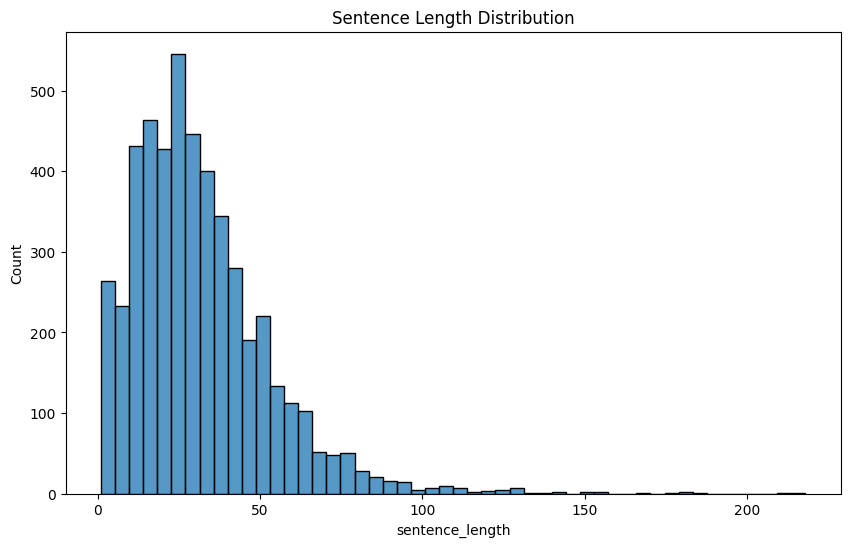

In [147]:
# YOUR CODE HERE - CREATE A DATASET FOR THE CLASSIFICATION TASK OF AUTHORSHIP ATTRIBUTION

# since we want to classify the disputed papers,
# let's remove them from the dataset into their own dataset.

disputed_authors = corpus[corpus['target'] == 'dispt']

# It stands to reason that the disputed papers could be co-authored, so
# let's remove them from the dataset and use them later. Our first task
# is to classify the disputed papers wrt to the question: For any given
# disputed paper, is it more likely to be authored by Hamilton or Madison?

coauthored = corpus[corpus['target'] == 'HM']

# remove the coauthored papers from the dataset
corpus = corpus[corpus['target'] != 'HM']

# since the disputed authors are either Hamilton or Madison, we can
# remove Jay from the dataset. We will hold Jay off for now, but we might
# want to experiment with Jay later.

# create a mask to filter out Jay
jay = corpus[corpus['target'] == 'Jay']

# use the mask to remove jay from the dataset
corpus = corpus[corpus['target'] != 'Jay']

# remove disputed papers from the corpus
corpus = corpus[corpus['target'] != 'dispt']

# plot the sentence length distribution
plt.figure(figsize=(10, 6))
sns.histplot(corpus['sentence_length'], bins=50)
plt.title('Sentence Length Distribution')
plt.show()

### Plot the distribution of the number of papers written by each author.

In [148]:
# YOUR CODE HERE - Visualize the distribution of the sentence lengths (what is the quartile distribution of the sentence lengths?)
import numpy as np

# get the 95th percentile of the sentence length
max_len = np.percentile(corpus['sentence_length'], 95)
max_len

70.0

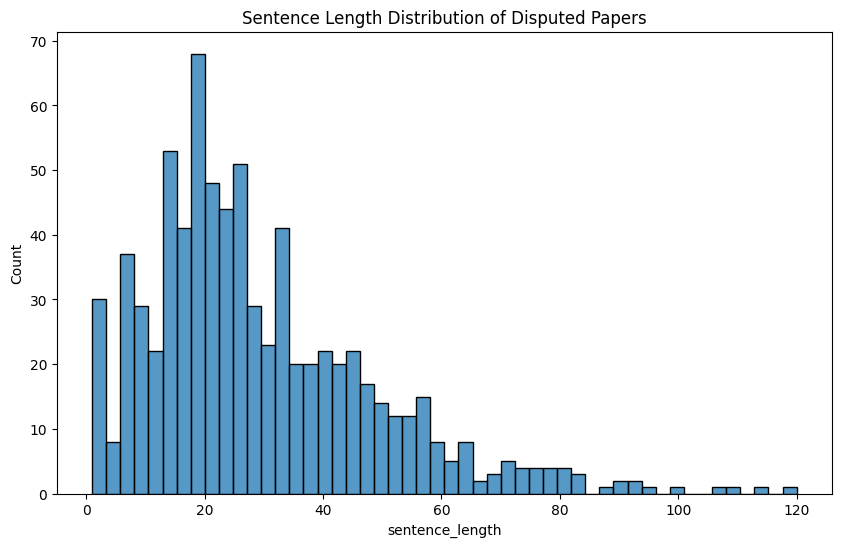

In [149]:
# Plot the sentence distribution of the disputed papers
plt.figure(figsize=(10, 6))
sns.histplot(disputed_authors['sentence_length'], bins=50)
plt.title('Sentence Length Distribution of Disputed Papers')
plt.show();

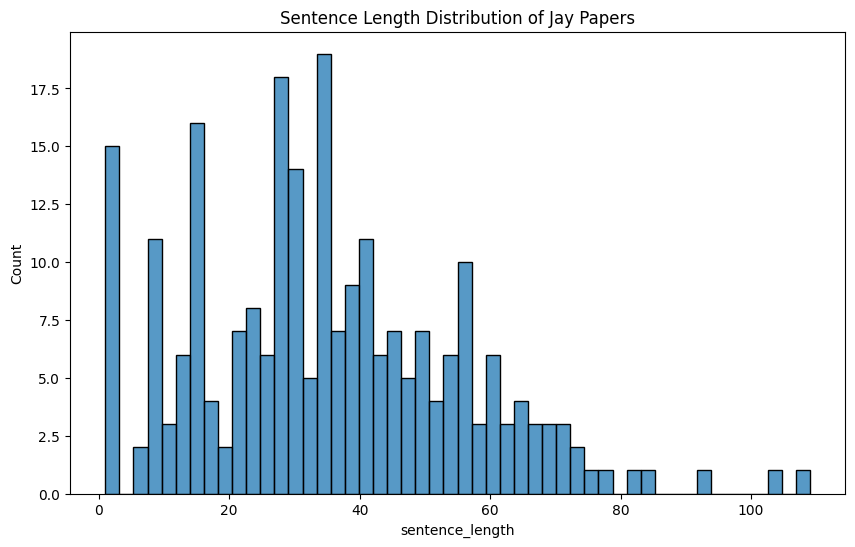

In [150]:
# Plot the sentence distribution of the jay papers
plt.figure(figsize=(10, 6))
sns.histplot(jay['sentence_length'], bins=50)
plt.title('Sentence Length Distribution of Jay Papers')
plt.show();

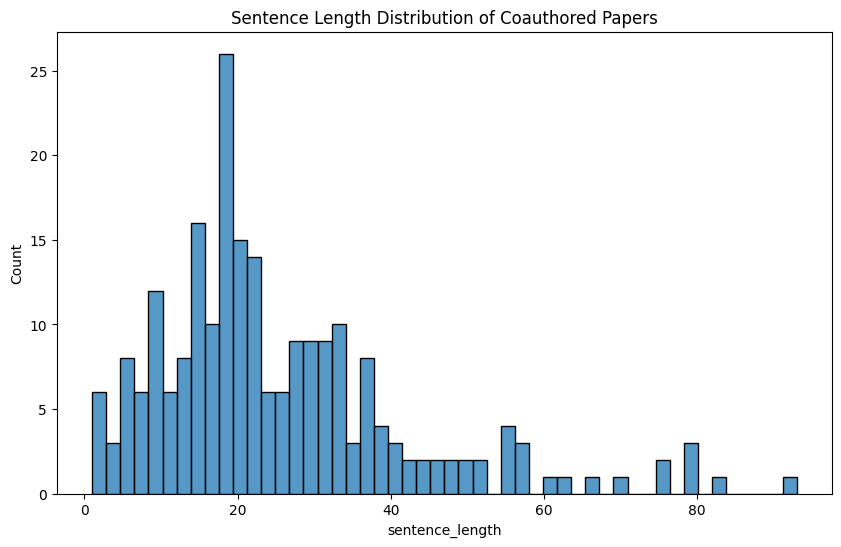

In [151]:
# Plot the sentence distribution of the coauthored papers
plt.figure(figsize=(10, 6))
sns.histplot(coauthored['sentence_length'], bins=50)
plt.title('Sentence Length Distribution of Coauthored Papers')
plt.show();

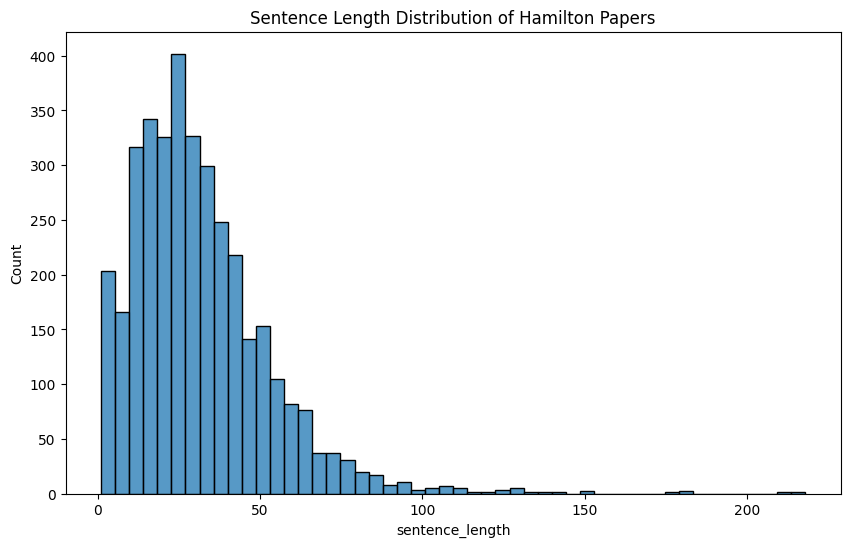

In [152]:
# Plot the sentence distribution of the Hamilton papers
plt.figure(figsize=(10, 6))
sns.histplot(corpus[corpus['target'] == 'Hamilton']['sentence_length'], bins=50)
plt.title('Sentence Length Distribution of Hamilton Papers')
plt.show();

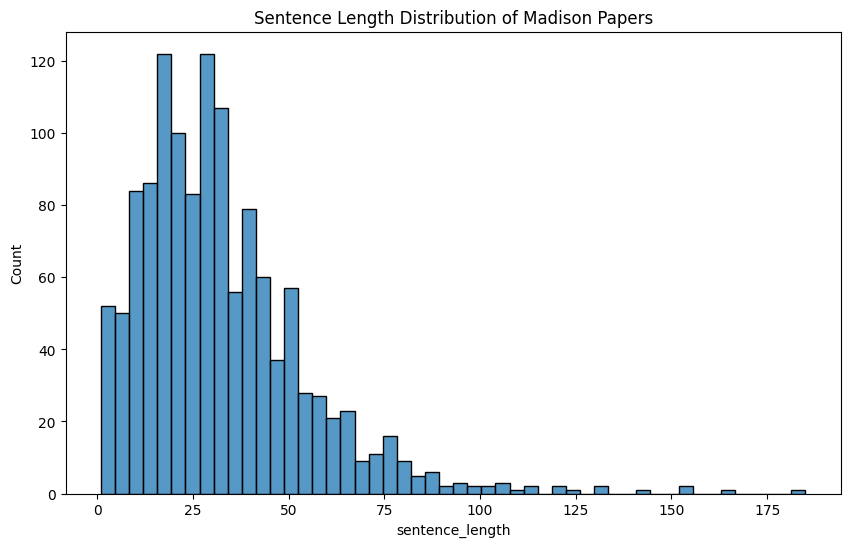

In [153]:
# Plot the sentence distribution of the Madison papers
plt.figure(figsize=(10, 6))
sns.histplot(corpus[corpus['target'] == 'Madison']['sentence_length'], bins=50)
plt.title('Sentence Length Distribution of Madison Papers')
plt.show();

### Plot the distribution of sentence lengths for each author.

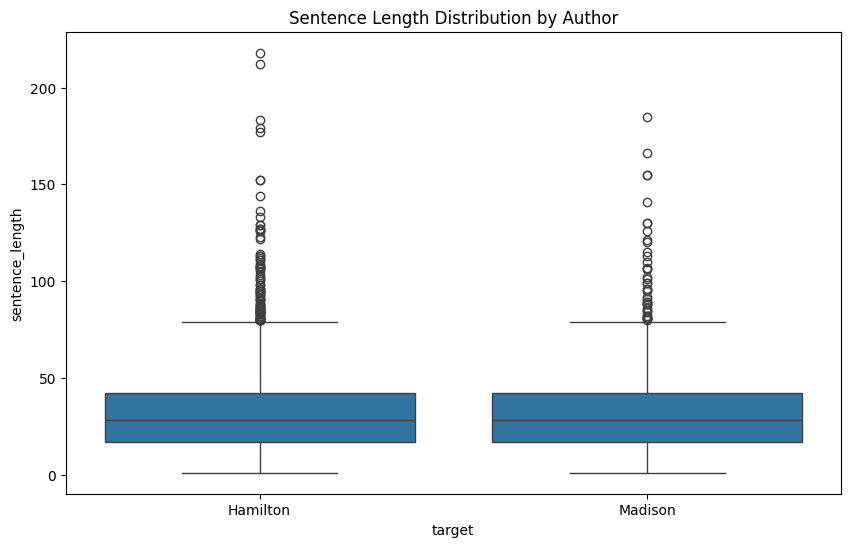

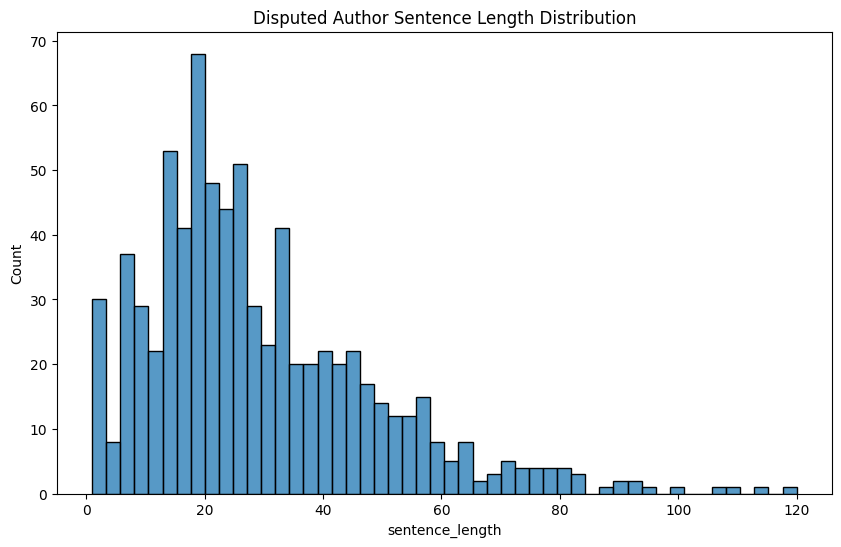

In [154]:
# YOUR CODE HERE - Visualize the distribution of sentence lengths according to the authorship
# plot the sentence length according to the author
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='sentence_length', data=corpus)
plt.title('Sentence Length Distribution by Author')
plt.show()

# plot the disputed_author sentence length and distribution
plt.figure(figsize=(10, 6))
sns.histplot(disputed_authors['sentence_length'], bins=50)
plt.title('Disputed Author Sentence Length Distribution')
plt.show()

### Prepare dataset for training

Prepare a training, validation, and test dataset. What is your X and y? What is the size of your training, validation, and test dataset?

In [155]:
from sklearn.model_selection import train_test_split

X_train, x_val, y_train, y_val = train_test_split(corpus['sentences'],
                                                  corpus['target'],
                                                  test_size=0.2,
                                                  stratify=corpus['target'],
                                                  random_state=42
                                )

print(f'Training samples: {len(X_train)}')
print(f'Validation samples: {len(x_val)}')

Training samples: 3904
Validation samples: 977


#### Visualize some random samples

In [156]:
import random

# sample a random sentence from the training set
random_idx = random.randint(0, len(X_train))
print(f'Random sentence: {X_train.iloc[random_idx]}')
print(f'Author: {y_train.iloc[random_idx]}')

Random sentence: 1.
Author: Hamilton


#### Plot the distribution of training and validation samples

Have you split the dataset in a stratified manner? Explain why it is important to split the dataset in a stratified manner. If you have not, explain why you did not split the dataset in a stratified manner. See the documentation for [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) for more information.

#### Plot the datasets

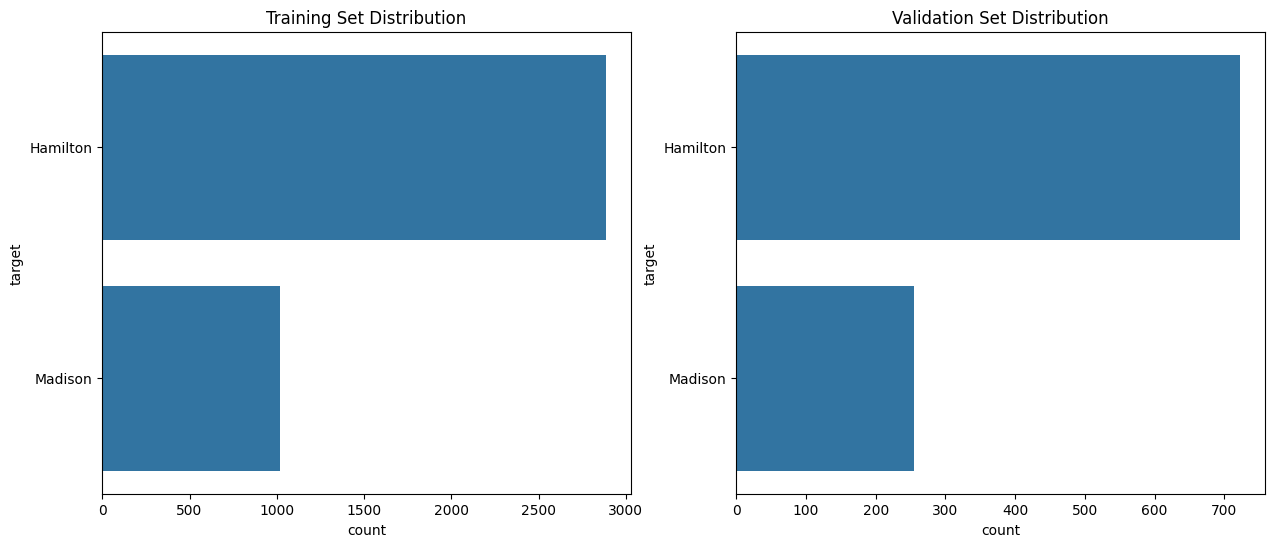

In [157]:
# plot the distribution of the target classes in the training and validation set on a countplot
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
# first plot is the training set
sns.countplot(y_train, ax=ax[0])
ax[0].set_title('Training Set Distribution')
# second plot is the validation set
sns.countplot(y_val, ax=ax[1])
ax[1].set_title('Validation Set Distribution')
plt.show()

#### Convert the target labels to one hot encodings

In [158]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)

y_train_ohe = ohe.fit_transform(y_train.values.reshape(-1, 1))
y_val_ohe = ohe.transform(y_val.values.reshape(-1, 1))

print(f'One hot encoded training labels shape: {y_train_ohe.shape}')
print(f'One hot encoded validation labels shape: {y_val_ohe.shape}')

One hot encoded training labels shape: (3904, 2)
One hot encoded validation labels shape: (977, 2)


In [159]:
y_train_ohe[:5], y_train[:5]

(array([[1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.]]),
 84    Hamilton
 57    Hamilton
 44    Hamilton
 18    Hamilton
 24    Hamilton
 Name: target, dtype: object)

#### Encode the labels

In [160]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_le = label_encoder.fit_transform(y_train)
y_val_le = label_encoder.transform(y_val)

print(f'Label encoded training labels shape: {y_train_le.shape}')
print(f'Label encoded validation labels shape: {y_val_le.shape}')

Label encoded training labels shape: (3904,)
Label encoded validation labels shape: (977,)


In [161]:
for i in range(5):
    print(f'Original label: {y_train.iloc[i]} - Label encoded: {y_train_le[i]}')

Original label: Hamilton - Label encoded: 0
Original label: Hamilton - Label encoded: 0
Original label: Hamilton - Label encoded: 0
Original label: Hamilton - Label encoded: 0
Original label: Hamilton - Label encoded: 0


In [162]:
num_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_
num_classes, class_names

(2, array(['Hamilton', 'Madison'], dtype=object))

## Train a TF-IDF model

In [163]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [164]:
text_clf = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', SVC(kernel='linear', C=1.0, random_state=42))
])

# fit the model
text_clf.fit(X_train, y_train_le)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clf', SVC(kernel='linear', random_state=42))])

In [165]:
text_clf.score(x_val, y_val_le)

0.8085977482088025

In [166]:
# let's use grid search to find the best hyperparameters for the model
from sklearn.model_selection import GridSearchCV

parameters = {
    'tfidf__ngram_range': [(1, 1), (1, 2), (2, 2)],
    'tfidf__max_df': [0.5, 0.75, 1.0],
    'tfidf__min_df': [1, 5, 10],
    'clf__C': [0.1, 1.0, 15.0]
}

gs_clf = GridSearchCV(text_clf, parameters, cv=5, n_jobs=-1)
gs_clf = gs_clf.fit(X_train, y_train_le)

print(f'{gs_clf.best_params_=}, {gs_clf.best_score_=}')

gs_clf.score(x_val, y_val_le)

gs_clf.best_params_={'clf__C': 15.0, 'tfidf__max_df': 0.5, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}, gs_clf.best_score_=0.8219760990183526


0.8249744114636642

Accuracy: 0.8219760990183526


In [167]:
# save the best model
import joblib

joblib.dump(gs_clf, 'authorship_attribution_model.pkl')

['authorship_attribution_model.pkl']

### Explain the TF-IDF model

- What is the TF-IDF model?
- How does the TF-IDF model work?
- What are the hyperparameters of the TF-IDF model?
- How do you select the hyperparameters of the TF-IDF model?
- Why is it helpful to establish a baseline model?

## Inference on the disputed papers

Let's use our model above to predict the authorship of the disputed papers.

In [169]:
# load the model
model = joblib.load('authorship_attribution_model.pkl')

In [170]:
# Run inference on the disputed papers
disputed_predictions = model.predict(disputed_authors['sentences'])

In [171]:

# for a disputed paper plot the predicted probabilities over the classes and sentence order
import matplotlib.pyplot as plt
import seaborn as sns

# add the predicted probabilities to the disputed authors dataframe using the labels
disputed_authors['predicted'] = label_encoder.inverse_transform(disputed_predictions)

# let's plot the authorship classification for the disputed paper 49
dp_49 = disputed_authors[disputed_authors['paper_id'] == '49']

<ipython-input-171-509b27b1d1a3>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  disputed_authors['predicted'] = label_encoder.inverse_transform(disputed_predictions)


In [172]:
dp_49.head()

,text,paper_id,target,sentences,sentence_length,sentence_index,total_sentences,predicted
0,Method of Guarding Against the Encroachments o...,49,dispt,Method of Guarding Against the Encroachments o...,25,0,63,Hamilton
0,Method of Guarding Against the Encroachments o...,49,dispt,"Tuesday, February 5, 1788.",4,1,63,Madison
0,Method of Guarding Against the Encroachments o...,49,dispt,Author: Alexander Hamilton or James Madison,6,2,63,Madison
0,Method of Guarding Against the Encroachments o...,49,dispt,To the People of the State of New York:,9,3,63,Hamilton
0,Method of Guarding Against the Encroachments o...,49,dispt,"THE author of the ""Notes on the State of Virgi...",56,4,63,Hamilton


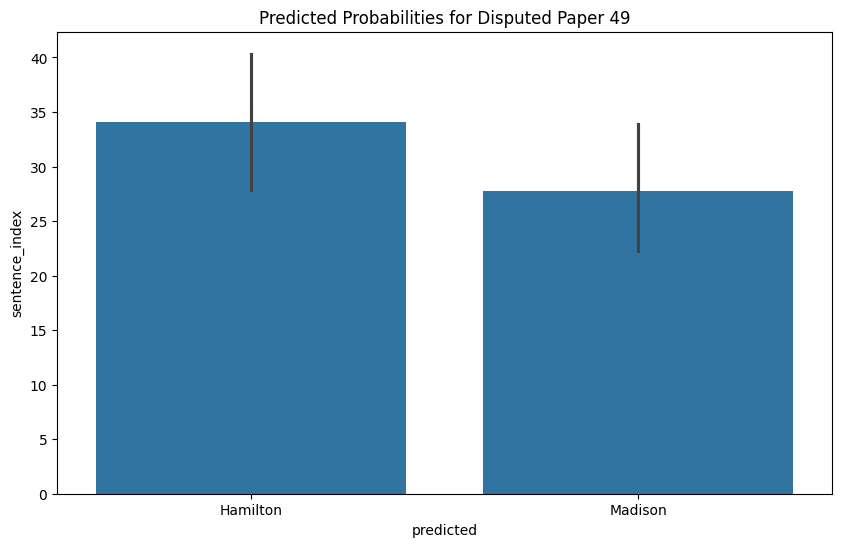

In [173]:
# plot the predicted probabilities for the disputed paper 49
plt.figure(figsize=(10, 6))
sns.barplot(x='predicted', y='sentence_index', data=dp_49)
plt.title('Predicted Probabilities for Disputed Paper 49')
plt.show()

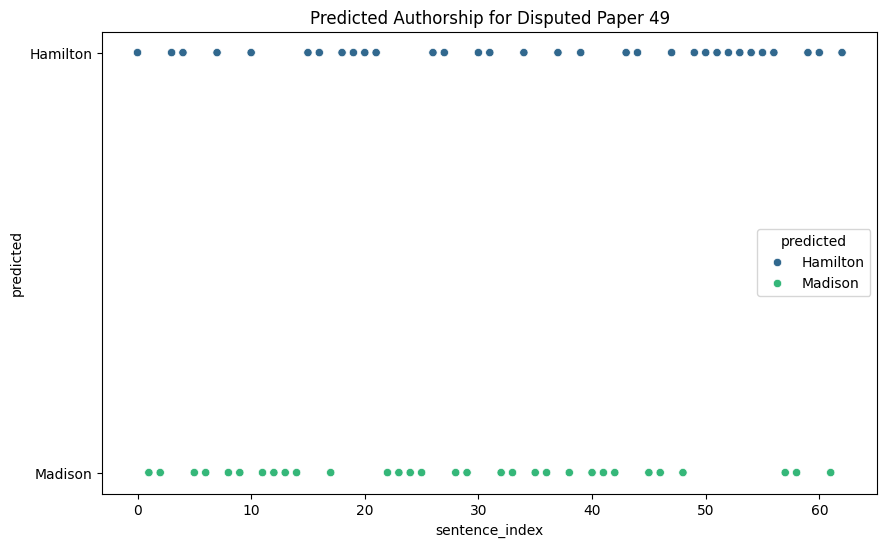

In [174]:
# for each sentence color the predicted author
plt.figure(figsize=(10, 6))
sns.scatterplot(x='sentence_index', y='predicted', data=dp_49, hue='predicted', palette='viridis')
plt.title('Predicted Authorship for Disputed Paper 49')
plt.show()


# Task 2: Train a Recurrent Neural Network (RNN) model

In the second part of this assignment, you are tasked with the following:

- Train a Recurrent Neural Network (RNN) model to predict the author of a paper.
- Evaluate the performance of your model and compare it against the baseline model.
- Explain your model architecture, hyperparameters, and the results of your model.
- Discuss the challenges you faced during the model training process and how you overcame them.
- Classify disputed papers using the Naive Bayes and RNN models
- Write a summary of your findings and the predictions of your model with respect to the disputed papers.

## Train a Recurrent Neural Network (RNN) model

### Vectorize your text data

Vectorize your text data with `tensorflow.keras.models.TextVectorization`. See the documentation here: [TextVectorization](https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization).

In [175]:
!pip install tensorflow

In [176]:
!pip install --upgrade tensorflow

In [177]:
import tensorflow as tf
print(tf.__version__)

2.16.1


In [178]:
!pip install tensorflow-text

In [179]:
print(tf.__version__)

2.16.1


In [180]:
from tensorflow.keras import layers
from tensorflow.keras import regularizers

### MY RNN MODEL

In [181]:
from tensorflow.keras.layers import TextVectorization


max_tokens = 20000  # maximum size of the vocabulary
output_sequence_length = 200  # length of output sequences
text_vectorizer = TextVectorization()

In [182]:
ohe = OneHotEncoder(sparse_output=False)

y_train_ohe = ohe.fit_transform(y_train.values.reshape(-1, 1))
y_val_ohe = ohe.transform(y_val.values.reshape(-1, 1))

In [183]:
train_sentence = authorship["sentences"].tolist()
text_vectorizer.adapt(train_sentence)

In [184]:
# Randomly visualize some of your vectorized textual data
import random
example_sent = random.choice(X_train.values) # change var name if you need to
print(f'Original text:\n{example_sent}')

Original text:
Both of them are comprised in the articles of Confederation, with this difference only, that the former is disembarrassed, by the plan of the convention, of an exception, under which treaties might be substantially frustrated by regulations of the States; and that a power of appointing and receiving "other public ministers and consuls," is expressly and very properly added to the former provision concerning ambassadors.


In [185]:
print(f'\nVectorized text:\n{text_vectorizer([example_sent])}')
print('Length of vector:', len(text_vectorizer([example_sent]).numpy()[0]))


Vectorized text:
[[  1   3   1   1   1  23   2   1   3  30 109   1   1   1 117   2   1   1
    1  50   2  65   3   2  71   3   1   1   1   1   1   1  98   1   1  50
    1   3   2  41  15 117  31  17   3  99  15   1  53   1   1  15   1   1
    1  15   1   1   1   9   2   1 136  16   1]]
Length of vector: 65


In [186]:
# examine the vocabulary
vocab = text_vectorizer.get_vocabulary()
print(f'Number of words in the vocabulary: {len(vocab)}')
print(f'Most common words in the vocabulary: {vocab[:5]}')
print(f'Least common words in the vocabulary: {vocab[-5:]}')

Number of words in the vocabulary: 221
Most common words in the vocabulary: ['', '[UNK]', 'the', 'of', 'from']
Least common words in the vocabulary: ['4', '29', '22', '19', '15']


In [187]:
# examine the config vars
text_vectorizer.get_config() # when you train your model, these parameters can be changed to perhaps improve performance

{'name': 'text_vectorization_1',
 'trainable': True,
 'dtype': 'float32',
 'max_tokens': None,
 'standardize': 'lower_and_strip_punctuation',
 'split': 'whitespace',
 'ngrams': None,
 'output_mode': 'int',
 'output_sequence_length': None,
 'pad_to_max_tokens': False,
 'sparse': False,
 'ragged': False,
 'vocabulary': None,
 'idf_weights': None,
 'encoding': 'utf-8',
 'vocabulary_size': 221}

In [188]:
# Adapt the text vectorizer to the training data
text_vectorizer.adapt(train_sentence)

### Create an embedding layer

In [189]:
token_embedding = tf.keras.layers.Embedding(input_dim=len(vocab),
                                            output_dim=128,
                                            mask_zero=True,
                                            name='token_embedding')

print(f'Sentence before vectorization: {example_sent}')
vectorized_sent = text_vectorizer(example_sent)
print(f'Sentence after vectorization: {vectorized_sent}')
embedded_sent = token_embedding(vectorized_sent)
print(f'Sentence after embedding: {embedded_sent}')

Sentence before vectorization: Both of them are comprised in the articles of Confederation, with this difference only, that the former is disembarrassed, by the plan of the convention, of an exception, under which treaties might be substantially frustrated by regulations of the States; and that a power of appointing and receiving "other public ministers and consuls," is expressly and very properly added to the former provision concerning ambassadors.
Sentence after vectorization: [  1   3   1   1   1  23   2   1   3  30 109   1   1   1 117   2   1   1
   1  50   2  65   3   2  71   3   1   1   1   1   1   1  98   1   1  50
   1   3   2  41  15 117  31  17   3  99  15   1  53   1   1  15   1   1
   1  15   1   1   1   9   2   1 136  16   1]
Sentence after embedding: [[-0.03555153 -0.02781504 -0.01111041 ...  0.01336726 -0.03136899
  -0.04301409]
 [ 0.01152252 -0.03486773  0.03842645 ... -0.03373422  0.0297012
  -0.02463015]
 [-0.03555153 -0.02781504 -0.01111041 ...  0.01336726 -0.031368

### Create Tensorflow Dataset

To efficiently train your model, you should create a `tf.data.Dataset` object. See the documentation here: [tf.data.Dataset](https://www.tensorflow.org/api_docs/python/tf/data/Dataset).

In [190]:
X_dataset = tf.data.Dataset.from_tensor_slices((X_train.values, y_train_ohe))
val_dataset = tf.data.Dataset.from_tensor_slices((x_val.values, y_val_ohe))

In [191]:
# print the first 5 samples
for sample in X_dataset.take(5):
    sentence, label = sample
    print(f'Sentence: {sentence} - Label: {label}')

Sentence: b'We have courts of common law, courts of probates (analogous in certain matters to the spiritual courts in England), a court of admiralty and a court of chancery.' - Label: [1. 0.]
Sentence: b'Article 3, sec. I. 2.' - Label: [1. 0.]
Sentence: b'IT IS sometimes asked, with an air of seeming triumph, what inducements could the States have, if disunited, to make war upon each other?' - Label: [1. 0.]
Sentence: b'It must in truth be acknowledged that, however these may differ in other respects, they in general appear to harmonize in this sentiment, at least, that there are material imperfections in our national system, and that something is necessary to be done to rescue us from impending anarchy.' - Label: [1. 0.]
Sentence: b'Pennsylvania and North Carolina are the two which contain the interdiction in these words: "As standing armies in time of peace are dangerous to liberty, THEY OUGHT NOT to be kept up."' - Label: [1. 0.]


### Create batches of data

Batch size is a model hyperparameter that defines the number of samples that will be propagated through the network. This number can and should be adjusted in consideration with model performance and compute memory. See the documentation here: [Batch size](https://www.tensorflow.org/guide/data).

In [192]:
BATCH_SIZE = 50

In [193]:
train_dataset = X_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

QUESTION: What does tf.data.AUTOTUNE do?

ANSWER: tf.data.AUTOTUNE is a feature that automatically tunes the performance of the data's pipeline. with prefetch(), it is determining the optimal nuber of elements to prefetch to improve the training efficiency.

### Design your model

In [194]:
# MODEL Hyperparameters
learning_rate = 0.0001
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
loss = 'categorical_crossentropy'
epochs = 8

In [195]:
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint

In [196]:
# Model architecture

inputs = tf.keras.Input(shape=(1,), dtype=tf.string)
x = text_vectorizer(inputs)

x = layers.Embedding(input_dim=len(vocab), output_dim=128, mask_zero=True)(x)
x = layers.LSTM(128, return_sequences=True, use_cudnn=False)(x)
x = layers.LSTM(64, use_cudnn=False)(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(32, activation='relu')(x)


outputs = layers.Dense(num_classes, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)
model.compile(loss=loss, optimizer=optimizer, metrics=['accuracy'])

In [197]:
# Define the checkpoint callback
checkpoint_callback = ModelCheckpoint(
    'best_model.keras',  #Path where the model will be saved, now ending with .keras
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
)

# Train the model or fit the model on the data
history = model.fit(train_dataset,epochs=epochs,validation_data=val_dataset,callbacks=[checkpoint_callback])

Epoch 1/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 70s 837ms/step - accuracy: 0.7272 - loss: 0.6515 - val_accuracy: 0.7390 - val_loss: 0.5813
Epoch 2/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 58s 533ms/step - accuracy: 0.7443 - loss: 0.5730 - val_accuracy: 0.7390 - val_loss: 0.5787
Epoch 3/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 501ms/step - accuracy: 0.7443 - loss: 0.5720 - val_accuracy: 0.7390 - val_loss: 0.5760
Epoch 4/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 476ms/step - accuracy: 0.7443 - loss: 0.5696 - val_accuracy: 0.7390 - val_loss: 0.5724
Epoch 5/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 482ms/step - accuracy: 0.7443 - loss: 0.5649 - val_accuracy: 0.7390 - val_loss: 0.5664
Epoch 6/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 42s 490ms/step - accuracy: 0.7455 - loss: 0.5511 - val_accuracy: 0.7533 - val_loss: 0.5567
Epoch 7/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 484ms/step - accuracy: 0.7509 - loss: 0.5422 - val_accuracy: 0.7615 - val_loss: 0.5347
Epoch 8/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 37s 466ms/step - accuracy: 0.7634 - loss: 0.5220 - val_accuracy: 0.

QUESTION: How can tensorflow automatically save the best performing model for you?

MY ANSWER:

TensorFlow can automatically save the best performing model using the ModelCheckpoint callback. An example of this is in the cell above: *checkpoint_callback = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)*. By specifying save_best_only=True and monitor='val_accuracy', TensorFlow will save the model only when there is an improvement in the validation accuracy during training. This ensures that the best version of the model, based on the specified metric, is saved to disk.

## Evaluate the performance of your model

In [198]:
# plot the training history
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.legend()
    plt.title('Training and Validation Loss')

    plt.show()

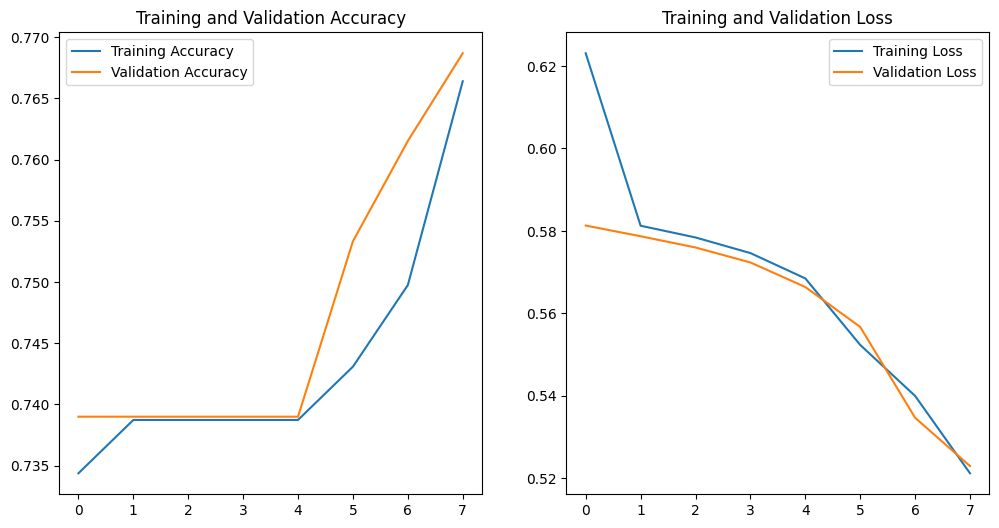

In [199]:
plot_history(history)

In [200]:
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f'Final Training Accuracy: {final_train_acc}')
print(f'Final Validation Accuracy: {final_val_acc}')

Final Training Accuracy: 0.7663934230804443
Final Validation Accuracy: 0.7686796188354492


QUESTION: Is your model overfit? Underfit?

MY ANSWER:
My model is not overfit nor is it underfit- my model appears to be well-tuned without significant overfitting or underfitting. The training and validation accuracy curves are close to each other, and both show an upward trend, indicating good learning and generalization. Similarly, the training and validation loss curves are close and both decrease over time, suggesting that the model is effectively minimizing error!


QUESTION:
Explain how bias and variance relate to training your model?

MY ANSWER:
Bias refers to the error introduced by a model when it makes assumptions about the data, often leading to oversimplification and underfitting if the model is too simple. I know that there is low bias here because both my training and validation accuracy is relatively high...also this also tells me that my model is sufficiently complex to capture the underlying patterns in the data without oversimplifying.
Variance is a model's sensitivity to fluctuations in the training data, and in this case, because the graph shows curves that are close to eachother for both training and validation, i know there is low variance/the model isn't overly sensitive and can generalize well to new unseen data.

## Explain your model architecture, hyperparameters, and the results of your model

- QUESTION: What hyperparameters resulted in the best performing model?
- QUESTION: What parameters resulted in the best performing model?
- QUESTION: What model architecture resulted in the best performing model?

MY ANSWER (for all 3 questions):
My best performing model came after several modifications to my hyperparameters and parameters. For my hyperparameters, I found that the LSTM layers with 128 and 64 units captured the sequential dependencies in the text data. The learning_rate of 0.0001 for the Adam optimizer resulted as the best step size, and the epochs set to 8 determined the number of times the entire training dataset was passed through the model. I also found that The BATCH_SIZE of 50 specified the number of samples processed before updating the model, which helped in efficient training and reduced memory usage. The parameters that were optimized and resulted in the best performing model include the weights and biases in the embedding layer, LSTM layers, and dense layers. In the embedding layer, the weights represent the dense vector for each token in the vocabulary. In the LSTM layers, the parameters include the weights connecting the input to the hidden units, recurrent weights connecting the hidden units to themselves, and the biases for each gate within the LSTM units. In the dense layers, the weights connect the input features to the neurons, and the biases are added to the weighted sum of inputs for each neuron. So yes, overall, the model architecture that resulted in the best performance included an embedding layer followed by two LSTM layers and a series of dense layers. Specifically, the architecture started with a TextVectorization layer to preprocess the input text, followed by an embedding layer to learn token representations. Two LSTM layers with 128 and 64 units respectively were used to capture sequential dependencies. A dropout layer with a rate of 0.5 was included to prevent overfitting, followed by a dense layer with 32 units and ReLU activation. The final output layer used a softmax activation to produce the class probabilities.

## Challenges faced during the model training process

QUESTION: Please explain any challenges you faced and how you overcame them.

MY ANSWER: During the model training process, I encountered several challenges. My first challenge was that, for some reason, my graph actually decreased instead of increased on the graph, for both the training and the testing. I knew this was because of some big mistake on my part, so it took me a bit to debug and realize what was causing the issue. Another issue that occured shortly after was overfitting actually. The model performed well on training data but, really bad on the validation data. To address this, I implemented dropout layers and experimented with different dropout rates, which helped improve generalization. A smaller challege was finding the right hyperparameters. It was time consuming to Another challenge was finding the optimal hyperparameters, such as learning rate, batch size, and the number of LSTM units. I used grid search and cross-validation techniques to systematically test various combinations and identify the best settings. Additionally, handling imbalanced data was problematic, leading to biased predictions. I mitigated this by using techniques such as class weighting and oversampling the minority class, which helped achieve more balanced model performance.-

## Classify the disputed authorship data

Using the Naive Bayes and RNN models, classify the disputed author sentences. Use visuaulizations and confusion matrices to communicate the decision outputs of your models. Are there any trends?

In [201]:
# load the model
model = joblib.load('authorship_attribution_model.pkl')
disputed_predictions = model.predict(disputed_authors['sentences'])

## Summary of your findings and predictions

- Classify the undetermined sentences with the Naive Bayes Model and your RNN model.

## My Naive Bayes Model

In [202]:
from sklearn.model_selection import train_test_split

X_train, x_val, y_train, y_val = train_test_split(corpus['sentences'],
                                                  corpus['target'],
                                                  test_size=0.2,
                                                  stratify=corpus['target'],
                                                  random_state=42
                                )

print(f'Training samples: {len(X_train)}')
print(f'Validation samples: {len(x_val)}')

Training samples: 3904
Validation samples: 977


In [229]:
import random

# sample a random sentence from the training set
random_idx = random.randint(0, len(X_train))
print(f'Random sentence: {X_train.iloc[random_idx]}')
print(f'Author: {y_train.iloc[random_idx]}')

Random sentence: Is a law proposed concerning private debts?
Author: Madison


In [204]:
from sklearn.feature_extraction.text import CountVectorizer

# Vectorize the training data
vectorizer = CountVectorizer(stop_words='english')
X_train_vectorized = vectorizer.fit_transform(X_train)
x_val_vectorized = vectorizer.transform(x_val)


In [205]:
X_train_vectorized.shape, x_val_vectorized.shape

((3904, 7083), (977, 7083))

In [206]:
X_train_vectorized[0], x_val_vectorized[0]

(<1x7083 sparse matrix of type '<class 'numpy.int64'>'
 	with 12 stored elements in Compressed Sparse Row format>,
 <1x7083 sparse matrix of type '<class 'numpy.int64'>'
 	with 10 stored elements in Compressed Sparse Row format>)

In [207]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_vectorized, y_train)


MultinomialNB()

In [208]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the validation set
y_pred = nb_model.predict(x_val_vectorized)

# Calculate evaluation metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, pos_label='Hamilton')
recall = recall_score(y_val, y_pred, pos_label='Hamilton')
f1 = f1_score(y_val, y_pred, pos_label='Hamilton')

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')


Accuracy: 0.8014329580348004
Precision: 0.8283582089552238
Recall: 0.9224376731301939


In [244]:
random_idx = random.randint(0, len(disputed_authors))
print(f'Random sentence: {disputed_authors["sentences"].iloc[random_idx]}')
new_text = [disputed_authors["sentences"].iloc[random_idx]]
new_text_vectorized = vectorizer.transform(new_text)
predicted_author = nb_model.predict(new_text_vectorized)
print(predicted_author)

Random sentence: Passing over the difference between the smallest and largest States, as Delaware, whose most numerous branch consists of twenty-one representatives, and Massachusetts, where it amounts to between three and four hundred, a very considerable difference is observable among States nearly equal in population.
['Madison']


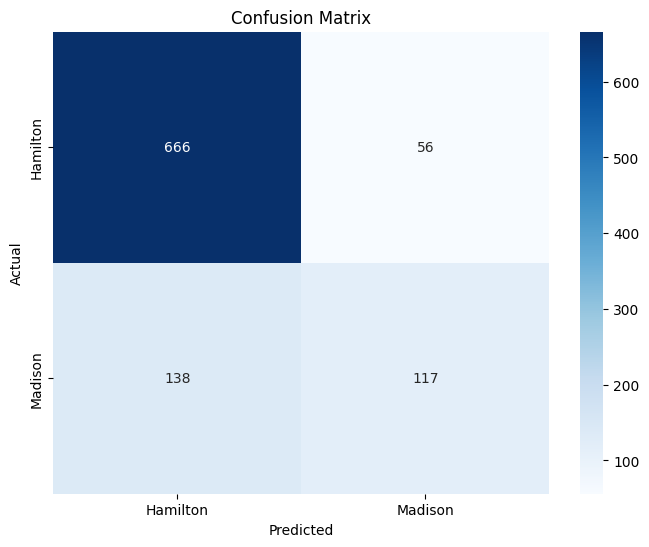

In [236]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cfm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cfm, annot=True, fmt='d', cmap='Blues', xticklabels=['Hamilton', 'Madison'], yticklabels=['Hamilton', 'Madison'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [211]:
disputed_authors.reset_index(drop=True, inplace=True)

In [212]:
disputed_authors

,text,paper_id,target,sentences,sentence_length,sentence_index,total_sentences,predicted
0,Method of Guarding Against the Encroachments o...,49,dispt,Method of Guarding Against the Encroachments o...,25,0,63,Hamilton
1,Method of Guarding Against the Encroachments o...,49,dispt,"Tuesday, February 5, 1788.",4,1,63,Madison
2,Method of Guarding Against the Encroachments o...,49,dispt,Author: Alexander Hamilton or James Madison,6,2,63,Madison
3,Method of Guarding Against the Encroachments o...,49,dispt,To the People of the State of New York:,9,3,63,Hamilton
4,Method of Guarding Against the Encroachments o...,49,dispt,"THE author of the ""Notes on the State of Virgi...",56,4,63,Hamilton
...,...,...,...,...,...,...,...,...
754,The Senate Continued For the Independent Journ...,63,dispt,It proves the irresistible force possessed by ...,20,88,93,Madison
755,The Senate Continued For the Independent Journ...,63,dispt,To these examples might be added that of Carth...,42,89,93,Madison
756,The Senate Continued For the Independent Journ...,63,dispt,Besides the conclusive evidence resulting from...,80,90,93,Madison
757,The Senate Continued For the Independent Journ...,63,dispt,Against the force of the immediate representat...,57,91,93,Madison


In [213]:
disputed_authors['nb_predicted_author'] = nb_model.predict(vectorizer.transform(disputed_authors['sentences']))
disputed_authors.head()

<ipython-input-213-407b29c03e51>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  disputed_authors['nb_predicted_author'] = nb_model.predict(vectorizer.transform(disputed_authors['sentences']))


,text,paper_id,target,sentences,sentence_length,sentence_index,total_sentences,predicted,nb_predicted_author
0,Method of Guarding Against the Encroachments o...,49,dispt,Method of Guarding Against the Encroachments o...,25,0,63,Hamilton,Madison
1,Method of Guarding Against the Encroachments o...,49,dispt,"Tuesday, February 5, 1788.",4,1,63,Madison,Hamilton
2,Method of Guarding Against the Encroachments o...,49,dispt,Author: Alexander Hamilton or James Madison,6,2,63,Madison,Hamilton
3,Method of Guarding Against the Encroachments o...,49,dispt,To the People of the State of New York:,9,3,63,Hamilton,Hamilton
4,Method of Guarding Against the Encroachments o...,49,dispt,"THE author of the ""Notes on the State of Virgi...",56,4,63,Hamilton,Madison


## My RNN Model

In [214]:
model = tf.keras.models.load_model('best_model.keras')

In [215]:
import numpy as np
import tensorflow as tf

sentence_to_predict = "The most material points of difference are these: First."

In [245]:
len(disputed_authors)

758

In [ ]:
random_idx = random.randint(0, len(disputed_authors))
print(f'Random sentence: {disputed_authors["sentences"].iloc[random_idx]}')
new_text = [disputed_authors["sentences"].iloc[random_idx]]
new_text_vectorized = vectorizer.transform(new_text)
predicted_author = nb_model.predict(new_text_vectorized)
print(predicted_author)

In [ ]:
#random_idx = random.randint(0, len(disputed_authors))
#print(f'Random sentence: {disputed_authors["sentences"].iloc[random_idx]}')
for idx in 0, len(disputed_authors):
  new_text = [disputed_authors["sentences"].iloc[idx]]
  new_text_vectorized = vectorizer.transform(new_text)
  predicted_author = nb_model.predict(new_text_vectorized)
  print(predicted_author)

In [262]:
random_idx = random.randint(0, len(disputed_authors))
print(f'Random sentence_to_predict: {disputed_authors["sentences"].iloc[random_idx]}')
sentence_to_predict = [disputed_authors["sentences"].iloc[random_idx]]
input_tensor = tf.constant([sentence_to_predict])
vectorized_sentence = text_vectorizer(input_tensor)
vectorized_sentence = tf.reshape(vectorized_sentence, shape=(-1,))
vectorized_sentence = tf.strings.as_string(vectorized_sentence)
prediction = model.predict(vectorized_sentence)
predicted_author_index = np.argmax(prediction, axis=1)[0]
predicted_author = ohe.categories_[0][predicted_author_index]
print(f'The predicted author for the sentence is: {predicted_author}')

Random sentence_to_predict: Within three years a census is to be taken, when the number may be augmented to one for every thirty thousand inhabitants; and within every successive period of ten years the census is to be renewed, and augmentations may continue to be made under the above limitation.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
The predicted author for the sentence is: Hamilton


In [217]:
vectorized_sentence

<tf.Tensor: shape=(9,), dtype=string, numpy=
array([b'2', b'1', b'1', b'1', b'3', b'1', b'1', b'116', b'1'],
      dtype=object)>

In [218]:
prediction

array([[0.54312277, 0.4568773 ],
       [0.54312277, 0.4568773 ],
       [0.54312277, 0.4568773 ],
       [0.54312277, 0.4568773 ],
       [0.54312277, 0.4568773 ],
       [0.54312277, 0.4568773 ],
       [0.54312277, 0.4568773 ],
       [0.54312277, 0.4568773 ],
       [0.54312277, 0.4568773 ]], dtype=float32)

In [219]:
predicted_author_index

0

In [220]:
predicted_author

'Hamilton'

In [221]:
for sentence in disputed_authors['sentences']:
    # Check if the sentence has no letters
    if not any(char.isalpha() for char in sentence):
        # Print the sentence with no letters
        print("Sentence with no letters:", sentence)

Sentence with no letters: ,


In [222]:
disputed_authors = disputed_authors[disputed_authors['sentences'] != ","]
#disputed_authors

In [223]:
def predict_author(sentence_to_predict):
    input_tensor = tf.constant([sentence_to_predict])
    vectorized_sentence = text_vectorizer(input_tensor)
    vectorized_sentence = tf.reshape(vectorized_sentence, shape=(-1,))
    vectorized_sentence = tf.strings.as_string(vectorized_sentence)
    prediction = model.predict(vectorized_sentence)
    predicted_author_index = np.argmax(prediction, axis=1)[0]
    predicted_author = ohe.categories_[0][predicted_author_index]
    return predicted_author

In [224]:
#my func

import pandas as pd
from tqdm import tqdm

tqdm.pandas()

disputed_authors['rnn_predicted_author'] = disputed_authors['sentences'].apply(predict_author)
print(corpus.head())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
1/1 ━━━━━━━

<ipython-input-224-92ad4d1504ad>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  disputed_authors['rnn_predicted_author'] = disputed_authors['sentences'].apply(predict_author)


In [293]:
disputed_authors

,text,paper_id,target,sentences,sentence_length,sentence_index,total_sentences,predicted,nb_predicted_author,rnn_predicted_author
0,Method of Guarding Against the Encroachments o...,49,dispt,Method of Guarding Against the Encroachments o...,25,0,63,Hamilton,Madison,Madison
1,Method of Guarding Against the Encroachments o...,49,dispt,"Tuesday, February 5, 1788.",4,1,63,Madison,Hamilton,Hamilton
2,Method of Guarding Against the Encroachments o...,49,dispt,Author: Alexander Hamilton or James Madison,6,2,63,Madison,Hamilton,Hamilton
3,Method of Guarding Against the Encroachments o...,49,dispt,To the People of the State of New York:,9,3,63,Hamilton,Hamilton,Hamilton
4,Method of Guarding Against the Encroachments o...,49,dispt,"THE author of the ""Notes on the State of Virgi...",56,4,63,Hamilton,Madison,Madison
...,...,...,...,...,...,...,...,...,...,...
753,The Senate Continued For the Independent Journ...,63,dispt,"The fact is the more remarkable, as unanimity ...",24,87,93,Madison,Madison,Hamilton
754,The Senate Continued For the Independent Journ...,63,dispt,It proves the irresistible force possessed by ...,20,88,93,Madison,Hamilton,Madison
755,The Senate Continued For the Independent Journ...,63,dispt,To these examples might be added that of Carth...,42,89,93,Madison,Madison,Hamilton
756,The Senate Continued For the Independent Journ...,63,dispt,Besides the conclusive evidence resulting from...,80,90,93,Madison,Hamilton,Hamilton


# Now that both models are put in their own columns, I will use a bar chart to show the difference between their predictions

In [307]:
my_texts = disputed_authors['paper_id'].unique()
my_texts

array(['49', '50', '51', '52', '53', '54', '55', '56', '57', '62', '63'],
      dtype=object)

In [313]:
df_49 = disputed_authors[disputed_authors['paper_id'] == '49']
df_50 = disputed_authors[disputed_authors['paper_id'] == '50']
df_51 = disputed_authors[disputed_authors['paper_id'] == '51']
df_52 = disputed_authors[disputed_authors['paper_id'] == '52']
df_53 = disputed_authors[disputed_authors['paper_id'] == '53']
df_54 = disputed_authors[disputed_authors['paper_id'] == '54']
df_55 = disputed_authors[disputed_authors['paper_id'] == '55']
df_56 = disputed_authors[disputed_authors['paper_id'] == '56']
df_57 = disputed_authors[disputed_authors['paper_id'] == '57']
df_62 = disputed_authors[disputed_authors['paper_id'] == '62']
df_63 = disputed_authors[disputed_authors['paper_id'] == '63']


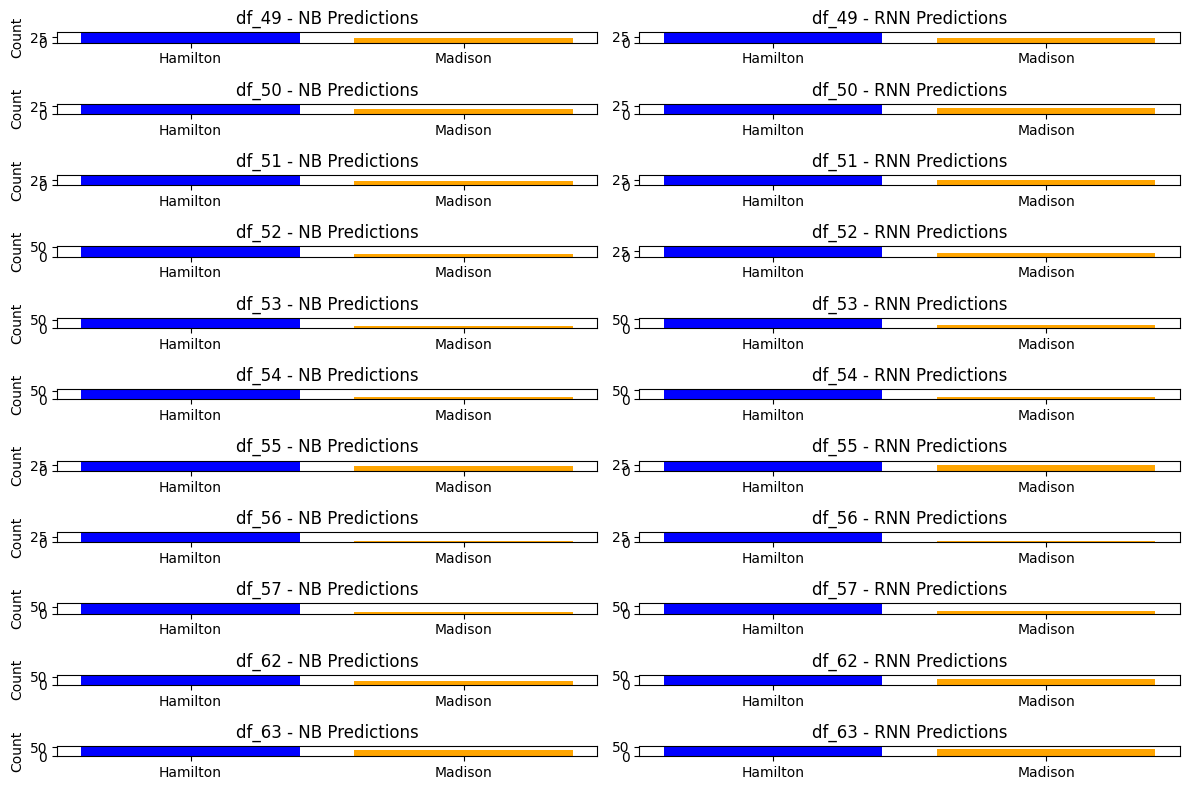

In [315]:
import matplotlib.pyplot as plt

# List containing the names of the DataFrames
df_names = ['df_49', 'df_50', 'df_51', 'df_52', 'df_53', 'df_54', 'df_55', 'df_56', 'df_57', 'df_62', 'df_63']

# Initialize lists to store counts
rb_hamilton_counts = []
rb_madison_counts = []
rnn_hamilton_counts = []
rnn_madison_counts = []

# Iterate through the list of DataFrame names
for name in df_names:
    df = globals()[name]  # Access DataFrame by name
    # Count Hamiltons and Madisons in 'rb_predicted_author' and 'rnn_predicted_author' columns
    rb_hamilton_counts.append((df['nb_predicted_author'] == 'Hamilton').sum())
    rb_madison_counts.append((df['nb_predicted_author'] == 'Madison').sum())
    rnn_hamilton_counts.append((df['rnn_predicted_author'] == 'Hamilton').sum())
    rnn_madison_counts.append((df['rnn_predicted_author'] == 'Madison').sum())

# Create bar charts
fig, axes = plt.subplots(nrows=len(df_names), ncols=2, figsize=(12, 8))
for i, name in enumerate(df_names):
    axes[i, 0].bar(['Hamilton', 'Madison'], [rb_hamilton_counts[i], rb_madison_counts[i]], color=['blue', 'orange'])
    axes[i, 0].set_title(name + ' - NB Predictions')
    axes[i, 0].set_ylabel('Count')

    axes[i, 1].bar(['Hamilton', 'Madison'], [rnn_hamilton_counts[i], rnn_madison_counts[i]], color=['blue', 'orange'])
    axes[i, 1].set_title(name + ' - RNN Predictions')

plt.tight_layout()
plt.show()


## Can't see this well! I will just do it twice...

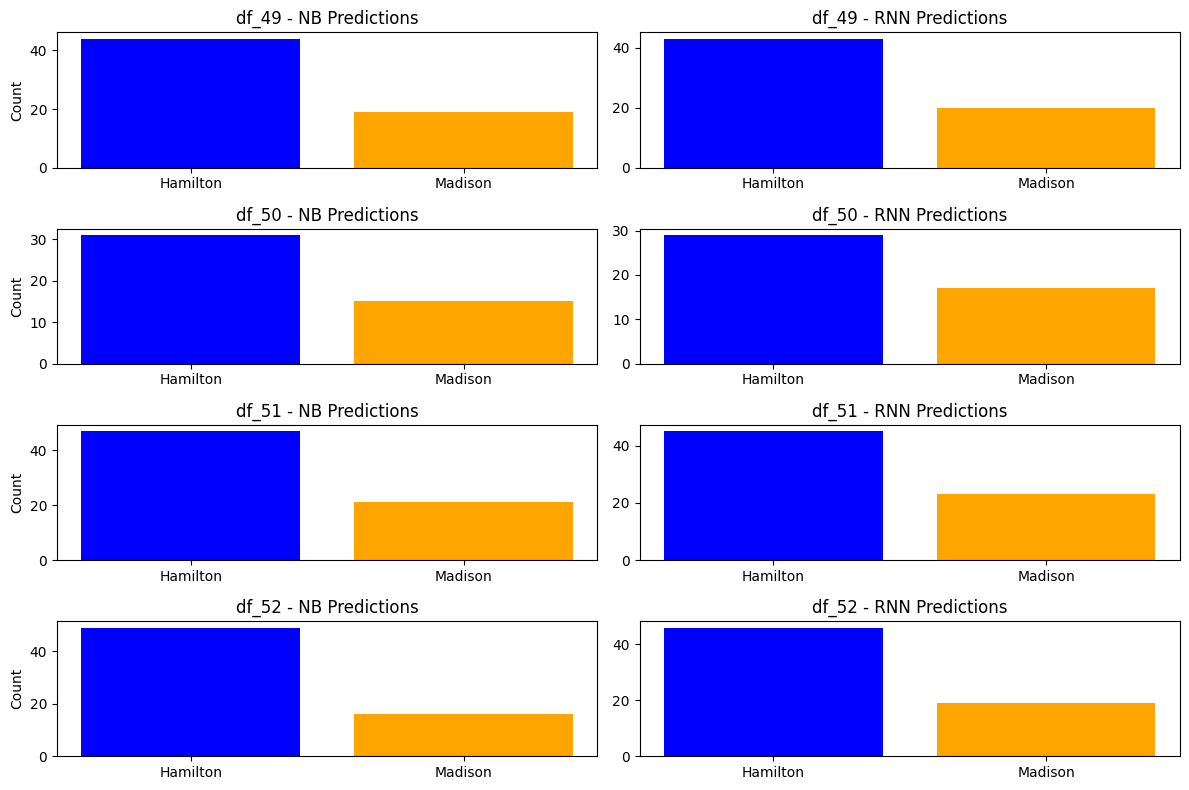

In [316]:
import matplotlib.pyplot as plt

# List containing the names of the DataFrames
df_names = ['df_49', 'df_50', 'df_51', 'df_52']

# Initialize lists to store counts
rb_hamilton_counts = []
rb_madison_counts = []
rnn_hamilton_counts = []
rnn_madison_counts = []

# Iterate through the list of DataFrame names
for name in df_names:
    df = globals()[name]  # Access DataFrame by name
    # Count Hamiltons and Madisons in 'rb_predicted_author' and 'rnn_predicted_author' columns
    rb_hamilton_counts.append((df['nb_predicted_author'] == 'Hamilton').sum())
    rb_madison_counts.append((df['nb_predicted_author'] == 'Madison').sum())
    rnn_hamilton_counts.append((df['rnn_predicted_author'] == 'Hamilton').sum())
    rnn_madison_counts.append((df['rnn_predicted_author'] == 'Madison').sum())

# Create bar charts
fig, axes = plt.subplots(nrows=len(df_names), ncols=2, figsize=(12, 8))
for i, name in enumerate(df_names):
    axes[i, 0].bar(['Hamilton', 'Madison'], [rb_hamilton_counts[i], rb_madison_counts[i]], color=['blue', 'orange'])
    axes[i, 0].set_title(name + ' - NB Predictions')
    axes[i, 0].set_ylabel('Count')

    axes[i, 1].bar(['Hamilton', 'Madison'], [rnn_hamilton_counts[i], rnn_madison_counts[i]], color=['blue', 'orange'])
    axes[i, 1].set_title(name + ' - RNN Predictions')

plt.tight_layout()
plt.show()


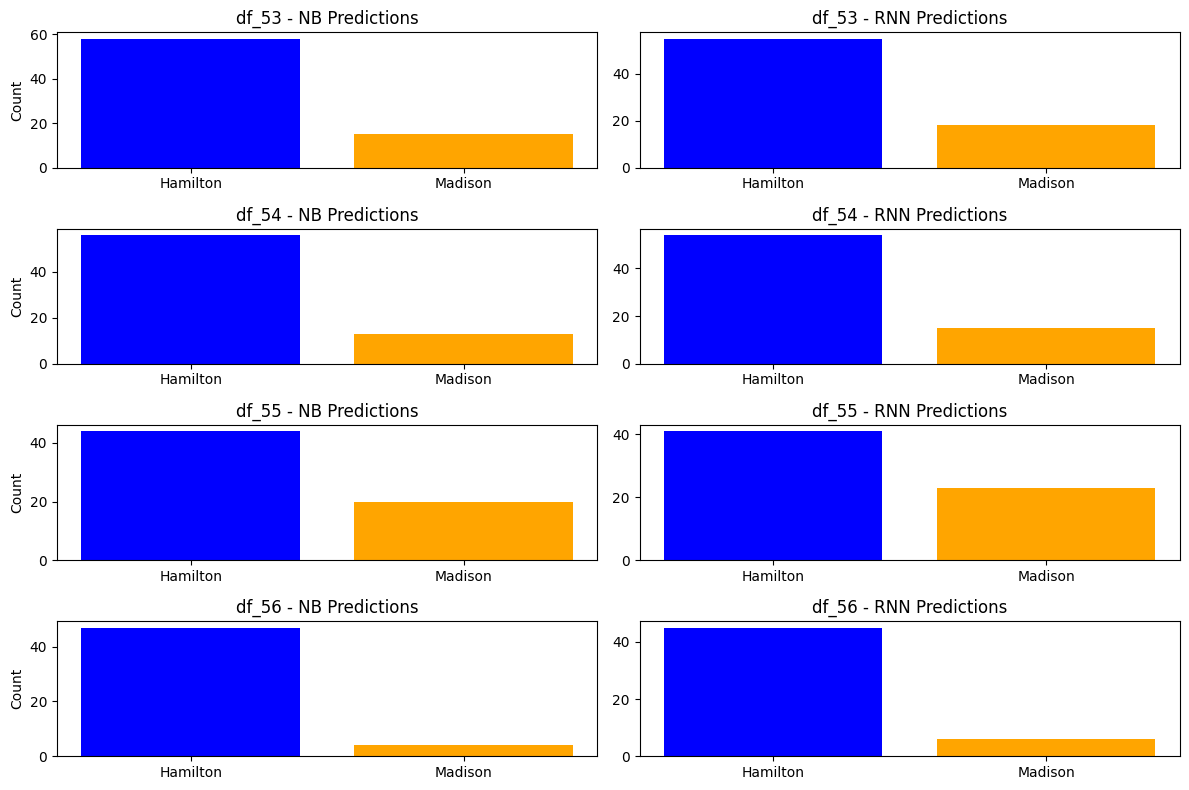

In [318]:
import matplotlib.pyplot as plt

# List containing the names of the DataFrames
df_names = ['df_53', 'df_54', 'df_55', 'df_56']

# Initialize lists to store counts
rb_hamilton_counts = []
rb_madison_counts = []
rnn_hamilton_counts = []
rnn_madison_counts = []

# Iterate through the list of DataFrame names
for name in df_names:
    df = globals()[name]  # Access DataFrame by name
    # Count Hamiltons and Madisons in 'rb_predicted_author' and 'rnn_predicted_author' columns
    rb_hamilton_counts.append((df['nb_predicted_author'] == 'Hamilton').sum())
    rb_madison_counts.append((df['nb_predicted_author'] == 'Madison').sum())
    rnn_hamilton_counts.append((df['rnn_predicted_author'] == 'Hamilton').sum())
    rnn_madison_counts.append((df['rnn_predicted_author'] == 'Madison').sum())

# Create bar charts
fig, axes = plt.subplots(nrows=len(df_names), ncols=2, figsize=(12, 8))
for i, name in enumerate(df_names):
    axes[i, 0].bar(['Hamilton', 'Madison'], [rb_hamilton_counts[i], rb_madison_counts[i]], color=['blue', 'orange'])
    axes[i, 0].set_title(name + ' - NB Predictions')
    axes[i, 0].set_ylabel('Count')

    axes[i, 1].bar(['Hamilton', 'Madison'], [rnn_hamilton_counts[i], rnn_madison_counts[i]], color=['blue', 'orange'])
    axes[i, 1].set_title(name + ' - RNN Predictions')

plt.tight_layout()
plt.show()


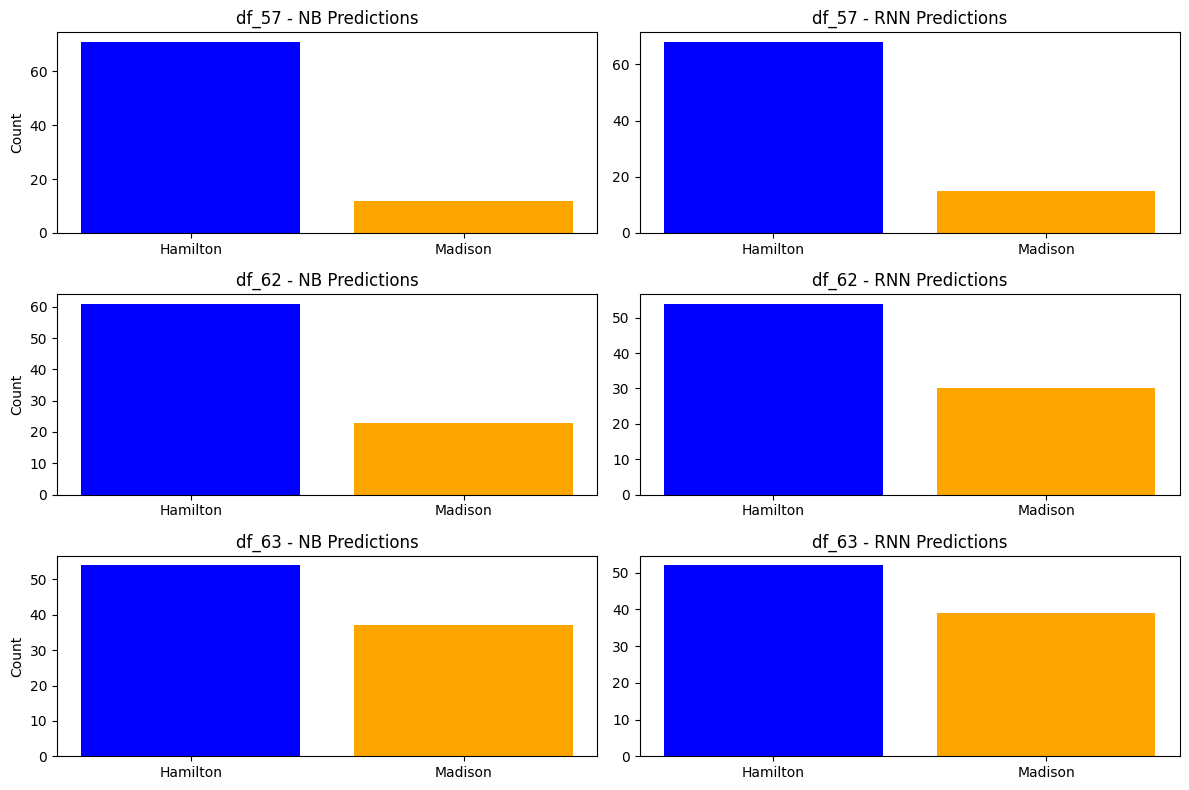

In [319]:
import matplotlib.pyplot as plt

# List containing the names of the DataFrames
df_names = ['df_57', 'df_62', 'df_63']

# Initialize lists to store counts
rb_hamilton_counts = []
rb_madison_counts = []
rnn_hamilton_counts = []
rnn_madison_counts = []

# Iterate through the list of DataFrame names
for name in df_names:
    df = globals()[name]  # Access DataFrame by name
    # Count Hamiltons and Madisons in 'rb_predicted_author' and 'rnn_predicted_author' columns
    rb_hamilton_counts.append((df['nb_predicted_author'] == 'Hamilton').sum())
    rb_madison_counts.append((df['nb_predicted_author'] == 'Madison').sum())
    rnn_hamilton_counts.append((df['rnn_predicted_author'] == 'Hamilton').sum())
    rnn_madison_counts.append((df['rnn_predicted_author'] == 'Madison').sum())

# Create bar charts
fig, axes = plt.subplots(nrows=len(df_names), ncols=2, figsize=(12, 8))
for i, name in enumerate(df_names):
    axes[i, 0].bar(['Hamilton', 'Madison'], [rb_hamilton_counts[i], rb_madison_counts[i]], color=['blue', 'orange'])
    axes[i, 0].set_title(name + ' - NB Predictions')
    axes[i, 0].set_ylabel('Count')

    axes[i, 1].bar(['Hamilton', 'Madison'], [rnn_hamilton_counts[i], rnn_madison_counts[i]], color=['blue', 'orange'])
    axes[i, 1].set_title(name + ' - RNN Predictions')

plt.tight_layout()
plt.show()


## My Analysis of My Visualizations:

QUESTION:
- Compare and contrast the results.
- What are your conclusions based on your experiments?

MY ANSWER:
Both of my Naive Bayes and RNN models consistently predict a higher number of sentences authored by Hamilton compared to Madison across all papers. Also, the distributions of Hamilton and Madison predictions are quite similar between the two models for each paper, indicating that both models generally agree on the classification. One thing that I found surprising was that there is a notable consistency in the ratio of Hamilton to Madison predictions across different papers within each model. Clearly the counts for Hamilton and Madison predictions vary slightly between the models, but the overall trend remains the same.
The similarity in results suggests that both models  learned similar patterns for diffrenciating between Hamilton's and Madison's writing styles, despite potential differences in their architectures.

QUESTION:
- Describe how a data science NLP solution relates to other methdologies for addressing author identification. Can we and should we value the RNN outputs? How does our RNN solution relate to issues of human values, judgments, and biases of opinion?

ANSWER:

Data science NLP solutions, like Naive Bayes and RNNs, can help identify authors by analyzing complex patterns in text. This project put me through tasks that really forced me to understand the complexity of NB and RNNs, and I can see how they work well alongside traditional methods such as the statistical analysis of writing style. I see that RNNs are useful because they understand context well. However, I know that if I were to do this again with a different dataset, I need to be careful and make sure I interpret correctly, because that would reflect on how I go about training my model, changing parameters/hyperparameters and more. We should value the RNN outputs to a certain extent, because sometimes we may never know if there was a bias that we hadn't considered. Our RNN solution should alwauys be considered with human insight and contet to reduce this bias. All an all, it will contribute the most accurate approach possible for better and fair identification!
